
# ➜ **Interpretación de modelos**

En este notebook se utilizarán las métricas de los modelos para analizar la importancia de las variables.

## **Librerias**

In [16]:
import joblib
import pandas as pd
import plotly.express as px
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
import shap

---

## **LightGBM**

In [17]:
MODELS_DIR = Path.cwd().parent / "models"

modelo_lightgbm = joblib.load(
    MODELS_DIR / "lightgbm_best_model.joblib"
)

preprocessor = modelo_lightgbm.named_steps["preprocessing"]
classifier = modelo_lightgbm.named_steps["classifier"]

features = preprocessor.get_feature_names_out()

importances = classifier.booster_.feature_importance(
    importance_type='gain'
)

dfFeatures = pd.DataFrame({
    "Variables": features,
    "Importancia": importances
})

dfFeatures_sorted = dfFeatures.sort_values(
    by="Importancia",
    ascending=False
)
print(dfFeatures_sorted)

fig = px.bar(
    dfFeatures_sorted,
    x="Variables",
    y="Importancia",
    title="Importancia de Variables - LightGBM"
)

fig.show()

                                            Variables  Importancia
8                            numericas__actualizacion  6596.544561
21  categoricas_nominales__cartera_consumo_con_lib...  6384.033021
15                           numericas__saldo_interes  4999.699053
16                           numericas__valorgarantia  4110.282408
20                            numericas__puntaje_data  3216.456582
1                              numericas__vinculacion  3182.210769
17                             numericas__ctasahorros  2765.170610
18                        numericas__curtotalingresos  1958.273905
12                             numericas__valor_cuota  1787.834698
2                                  numericas__aportes  1501.138022
14                           numericas__saldo_capital  1317.769858
22  categoricas_nominales__cartera_consumo_sin_lib...  1292.464583
13                          numericas__valor_prestamo  1264.608562
0                                    numericas__plazo  1025.89

El análisis de importancia de variables realizado con LightGBM permitió identificar cuáles características aportan mayor información al momento de predecir el default de un cliente. Para este análisis se utilizó la métrica gain, la cual mide cuánto contribuye cada variable a reducir el error del modelo durante la construcción de los árboles. A diferencia de métricas como split, que únicamente contabilizan cuántas veces una variable es utilizada, gain permite evaluar el aporte real de cada característica en el desempeño predictivo del modelo, por lo que resulta más adecuada para interpretar relevancia en problemas de clasificación.

Los resultados muestran que la variable más importante del modelo fue actualizacion, indicando que mantener la información actualizada dentro de la cooperativa tiene una fuerte relación con el comportamiento de pago de los clientes. Este hallazgo coincide con lo observado previamente en el EDA, donde los usuarios con datos desactualizados presentaban porcentajes considerablemente más altos de impago.

De igual forma, las variables relacionadas con el tipo de cartera también presentan una importancia muy alta, especialmente cartera_consumo_con_libranza, reforzando la idea de que la modalidad del crédito influye significativamente en el riesgo de default. Esto también resulta coherente con el análisis exploratorio, donde los créditos sin libranza mostraban tasas de impago mucho mayores.

Entre las variables numéricas más relevantes destacan saldo_interes, valorgarantia, puntaje_data, vinculacion y ctasahorros. En conjunto, estas variables sugieren que el modelo está capturando patrones asociados tanto al comportamiento financiero del cliente como a su estabilidad económica y relación histórica con la cooperativa. Particularmente, el puntaje_data confirma la importancia del historial crediticio como factor predictivo de incumplimiento.

Otro aspecto interesante es que variables como sexo, intestrato, grupo_edad y grupo_actividadeco presentan importancias considerablemente bajas dentro del modelo. Esto sugiere que, aunque algunas mostraban ligeras diferencias durante el EDA, su capacidad real para discriminar entre clientes con y sin default es limitada cuando se consideran conjuntamente con variables financieras más fuertes.

Finalmente, los resultados reflejan una alta coherencia entre el análisis exploratorio realizado previamente y el comportamiento final del modelo, ya que muchas de las variables que mostraban patrones diferenciadores durante el EDA terminaron siendo también las más relevantes para la predicción del default.

# ➜ **Recreación del conjunto de entrenamiento para el análisis con SHAP**

In [18]:
DATA_DIR = Path.cwd().parent / "data" / "processed"
datos_cooperativa = pd.read_parquet(DATA_DIR / "02_datos_ajustados_cooperativa.parquet")

columnas_seleccionadas = [
    'cartera', 
    'plazo', 
    'vinculacion', 
    'valor_cuota', 
    'valor_prestamo',
    'saldo_capital', 
    'saldo_interes', 
    'aportes', 
    'garantias',
    'valorgarantia', 
    'ctasahorros', 
    'edad', 
    'tipoasociado',
    'sexo', 
    'curtotalingresos',
    'curtotalegresos', 
    'intestrato', 
    'actualizacion', 
    'default',
    'puntaje_data', 
    'grupo_ciudad', 
    'grupo_edad',
    'grupo_actividadeco']

df_cooperativa = datos_cooperativa[columnas_seleccionadas]

In [19]:
X = df_cooperativa.drop(columns='default')
Y = df_cooperativa['default']


X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2, random_state=100
)

In [20]:
cols_numericas_enteras = ['plazo', 'vinculacion', 'aportes', 'garantias', 'edad', 'tipoasociado',
       'sexo', 'intestrato', 'actualizacion', 'grupo_ciudad', 'grupo_edad',
       'grupo_actividadeco']

cols_categoricas = ['cartera']

cols_flotantes = ['valor_cuota', 'valor_prestamo', 'saldo_capital', 'saldo_interes',
       'valorgarantia', 'ctasahorros', 'curtotalingresos', 'curtotalegresos',
       'puntaje_data']

In [21]:
categorical_pipeline = Pipeline(steps=[
    ('encoder', OneHotEncoder(handle_unknown='ignore'))      
])

categorical_pipeline

numerical_pipeline = Pipeline(steps=[
    ('scaler', StandardScaler())            
])

numerical_pipeline

preprocessor = ColumnTransformer(
    transformers=[
        ('numericas', numerical_pipeline, cols_numericas_enteras + cols_flotantes),
        ('categoricas_nominales', categorical_pipeline, cols_categoricas),
    ]
)


In [22]:
X_train_transformed = preprocessor.fit_transform(X_train)
X_test_transformed = preprocessor.transform(X_test)

In [23]:
feature_names = preprocessor.get_feature_names_out()

feature_names

array(['numericas__plazo', 'numericas__vinculacion', 'numericas__aportes',
       'numericas__garantias', 'numericas__edad',
       'numericas__tipoasociado', 'numericas__sexo',
       'numericas__intestrato', 'numericas__actualizacion',
       'numericas__grupo_ciudad', 'numericas__grupo_edad',
       'numericas__grupo_actividadeco', 'numericas__valor_cuota',
       'numericas__valor_prestamo', 'numericas__saldo_capital',
       'numericas__saldo_interes', 'numericas__valorgarantia',
       'numericas__ctasahorros', 'numericas__curtotalingresos',
       'numericas__curtotalegresos', 'numericas__puntaje_data',
       'categoricas_nominales__cartera_consumo_con_libranza',
       'categoricas_nominales__cartera_consumo_sin_libranza',
       'categoricas_nominales__cartera_vivienda'], dtype=object)

In [24]:
X_train_transformed = pd.DataFrame(X_train_transformed,columns=feature_names)
X_test_transformed = pd.DataFrame(X_test_transformed,columns=feature_names)

In [25]:
X_train_transformed

,numericas__plazo,numericas__vinculacion,numericas__aportes,numericas__garantias,numericas__edad,numericas__tipoasociado,numericas__sexo,numericas__intestrato,numericas__actualizacion,numericas__grupo_ciudad,...,numericas__saldo_capital,numericas__saldo_interes,numericas__valorgarantia,numericas__ctasahorros,numericas__curtotalingresos,numericas__curtotalegresos,numericas__puntaje_data,categoricas_nominales__cartera_consumo_con_libranza,categoricas_nominales__cartera_consumo_sin_libranza,categoricas_nominales__cartera_vivienda
0,-0.503952,0.628132,0.009240,-0.325871,0.005225,-1.110997,1.072434,-0.662210,-1.081030,1.082606,...,-0.174482,0.050347,-0.051717,-0.117693,-0.217765,-0.050271,0.255349,0.0,1.0,0.0
1,0.066579,0.726295,0.920940,-0.325871,-0.157305,0.900093,1.072434,0.417803,-1.081030,1.082606,...,-0.079412,-0.171956,-0.045032,0.240393,0.016755,-0.033887,0.901898,0.0,1.0,0.0
2,0.832496,-0.184489,-0.650294,-0.325871,-1.051219,0.900093,1.072434,-0.662210,0.925043,-0.015417,...,-0.032960,-0.179934,-0.056553,-0.119547,-0.214703,-0.053548,-2.362646,0.0,1.0,0.0
3,0.066579,1.342591,0.731995,-0.325871,0.817875,-1.110997,-0.932458,-0.662210,0.925043,-0.015417,...,0.137551,-0.150146,-0.025615,0.095046,0.148111,-0.021107,0.350741,1.0,0.0,0.0
4,0.637109,-0.123832,-0.074108,-0.325871,0.980404,0.900093,1.072434,0.417803,-1.081030,0.533595,...,-0.201714,-0.149129,-0.052328,0.080182,-0.341530,-0.046994,-1.726696,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10322,0.638672,1.569939,2.417931,-0.325871,0.167755,0.900093,-0.932458,0.417803,0.925043,-0.015417,...,0.046379,-0.045287,-0.034057,-0.116814,0.089654,-0.040440,0.753510,0.0,1.0,0.0
10323,0.091588,-0.496572,-0.001295,-0.325871,-0.401100,0.900093,-0.932458,0.417803,0.925043,0.533595,...,-0.194882,-0.167400,-0.051794,-0.095576,0.051089,0.025096,0.901898,0.0,1.0,0.0
10324,-0.202274,0.225295,-0.438388,-0.325871,-0.644894,0.900093,-0.932458,-1.742222,-1.081030,-2.211464,...,-0.272308,-0.143020,-0.054999,-0.124001,-0.251433,-0.053548,-2.246055,0.0,1.0,0.0
10325,-1.076045,-0.548895,-0.508791,-0.325871,-0.969954,0.900093,-0.932458,0.417803,-1.081030,1.082606,...,-0.259193,-0.140162,-0.055515,-0.123953,-0.187995,-0.040440,-0.942357,0.0,1.0,0.0


# ➜ **Análisis de importancia de variables son SHAP LightGBM**

c:\Users\Usuario\Desktop\Universidad\Semestre 11 FINAL\PROYIFINAL AHORA SI TE LO JURO\credit-risk-classification\.venv\lib\site-packages\shap\explainers\_tree.py:586: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


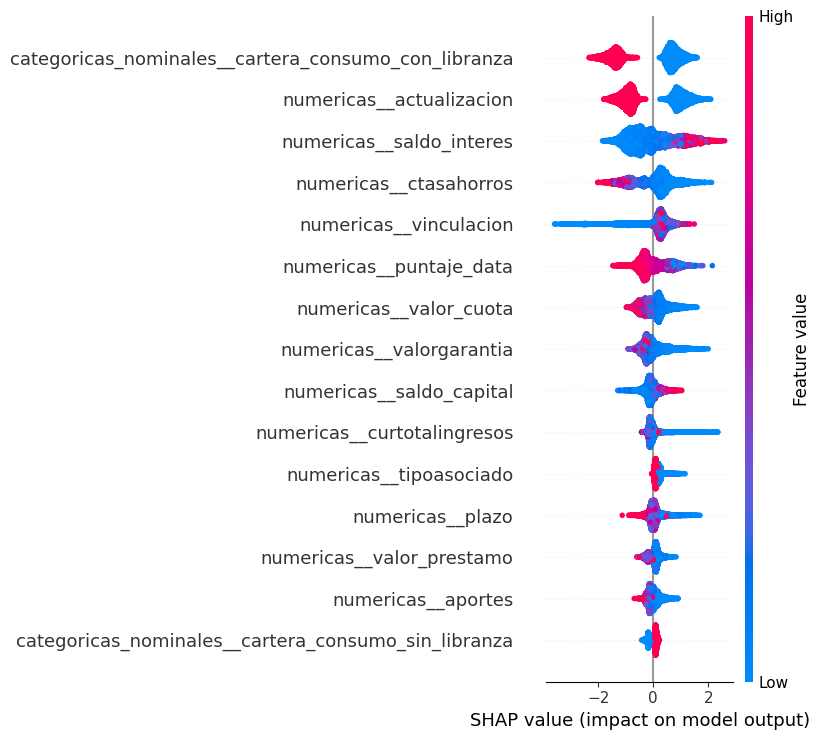

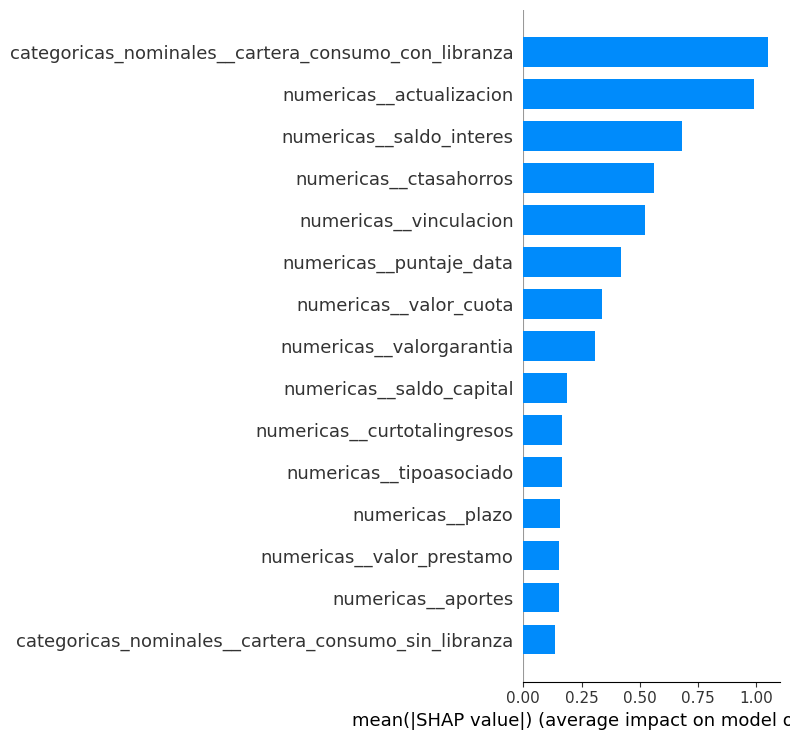

In [26]:
preprocessor = modelo_lightgbm.named_steps["preprocessing"]
classifier = modelo_lightgbm.named_steps["classifier"]

explainer = shap.TreeExplainer(classifier)

# Calcular valores SHAP
shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    max_display=15
)


shap.summary_plot(
    shap_values,
    X_train_transformed,
    plot_type="bar",
    max_display=15
)

El análisis de interpretabilidad con SHAP permitió validar y complementar los resultados obtenidos previamente mediante la importancia por gain en el modelo LightGBM.

La principal diferencia observada fue que la variable cartera_consumo_con_libranza pasó a ocupar el primer lugar en importancia, superando a actualizacion, que anteriormente había sido la variable más relevante bajo la métrica gain. Esto resulta interesante, ya que durante el EDA se observó una mayor proporción de impago en la categoría consumo_sin_libranza, mientras que en SHAP esta última presenta una importancia considerablemente menor dentro de las decisiones globales del modelo.

Sin embargo, a pesar de este cambio en el orden, se mantiene una consistencia importante entre ambos análisis, ya que las mismas variables continúan dominando el modelo: actualizacion, variables asociadas al tipo de cartera, saldo_interes, ctasahorros, puntaje_data y otras variables financieras relacionadas con el comportamiento crediticio del cliente.

Esto permite reforzar la idea de que el verdadero poder predictivo del modelo se encuentra principalmente en las variables financieras y de comportamiento económico, más que en variables demográficas o sociales. Variables como sexo, grupo_edad, tipoasociado o intestrato continúan mostrando una importancia relativamente baja, lo cual además coincide con lo observado previamente en el análisis exploratorio de datos.

Adicionalmente, SHAP aporta una ventaja importante frente a la métrica gain, ya que permite interpretar el impacto promedio real que tiene cada variable sobre las predicciones del modelo, ofreciendo una visión más cercana al comportamiento individual de cada observación y no únicamente a la construcción interna de los árboles.

En general, el análisis SHAP confirma que el modelo LightGBM basa gran parte de sus decisiones en variables relacionadas con estabilidad financiera, historial crediticio y capacidad económica del cliente, lo cual resulta coherente desde la perspectiva del negocio y del problema de predicción de impago.

## **GradientBoostingClassifier**

In [27]:
MODELS_DIR = Path.cwd().parent / "models"

modelo_gbc = joblib.load(MODELS_DIR / "gbc_best_model.joblib")

preprocessor = modelo_gbc.named_steps["preprocessing"]
classifier = modelo_gbc.named_steps["classifier"]


preprocessor

classifier

# Acceder al preprocesador y al clasificador usando 'named_steps'
features = preprocessor.get_feature_names_out()
importances = classifier.feature_importances_

# Crear y ordenar el DataFrame con las importancias
dfFeatures = pd.DataFrame({"Variables": features, "Importancia": importances})
dfFeatures_sorted = dfFeatures.sort_values(by="Importancia", ascending=False)
print(dfFeatures_sorted)

fig = px.bar(
    dfFeatures_sorted,
    x="Variables",
    y="Importancia",
    title="Importancia de las Variables",
    # text="Importancia"
)

fig.show()

                                            Variables  Importancia
8                            numericas__actualizacion     0.142486
15                           numericas__saldo_interes     0.131199
22  categoricas_nominales__cartera_consumo_sin_lib...     0.094185
18                        numericas__curtotalingresos     0.090512
17                             numericas__ctasahorros     0.088813
16                           numericas__valorgarantia     0.088544
20                            numericas__puntaje_data     0.066907
12                             numericas__valor_cuota     0.055546
1                              numericas__vinculacion     0.054337
21  categoricas_nominales__cartera_consumo_con_lib...     0.040752
2                                  numericas__aportes     0.037377
14                           numericas__saldo_capital     0.029308
13                          numericas__valor_prestamo     0.022259
0                                    numericas__plazo     0.01

A diferencia de LightGBM, donde se utilizó explícitamente la métrica gain, en Gradient Boosting la importancia se calcula mediante la reducción promedio de impureza generada por cada variable a lo largo de los árboles del modelo. En términos simples, esto representa cuánto ayuda cada variable a mejorar las decisiones de clasificación dentro del conjunto de árboles.

Los resultados obtenidos muestran nuevamente una alta coherencia con el análisis exploratorio realizado previamente. La variable más importante del modelo vuelve a ser actualizacion, lo que refuerza la idea de que mantener información actualizada dentro de la cooperativa está fuertemente relacionado con un menor riesgo de impago. Este comportamiento ya había sido evidenciado durante el EDA, donde los clientes con información desactualizada presentaban tasas de default considerablemente mayores.

Asimismo, variables financieras como saldo_interes, curtotalingresos, ctasahorros, valorgarantia y puntaje_data aparecen entre las más relevantes del modelo. Esto indica que Gradient Boosting otorga un peso importante tanto a la capacidad económica del cliente como a variables relacionadas con el comportamiento financiero y crediticio.

Resulta especialmente interesante que cartera_consumo_sin_libranza tenga una importancia considerablemente alta dentro del modelo, reforzando nuevamente la hipótesis planteada en el EDA acerca de que este tipo de cartera presenta un mayor riesgo de impago frente a créditos con libranza. De esta manera, el modelo logra capturar patrones que coinciden directamente con la lógica del negocio financiero.

También se observa que variables como sexo, grupo_edad, grupo_ciudad, intestrato y garantias poseen una importancia muy baja dentro del modelo. Esto sugiere que, aunque algunas de estas variables mostraban ciertas diferencias descriptivas durante el análisis exploratorio, su capacidad predictiva real es limitada cuando el modelo dispone de variables financieras más fuertes y directamente relacionadas con el riesgo crediticio.

Finalmente, el hecho de que tanto LightGBM como Gradient Boosting coincidan en señalar variables similares como las más importantes aporta mayor confianza sobre la consistencia de los patrones encontrados en el dataset. En ambos modelos predominan variables asociadas a comportamiento financiero, historial crediticio y estabilidad económica del cliente, lo que resulta coherente con la naturaleza del problema de predicción de default.

# ➜ **Análisis de importancia de variables son SHAP GBC**

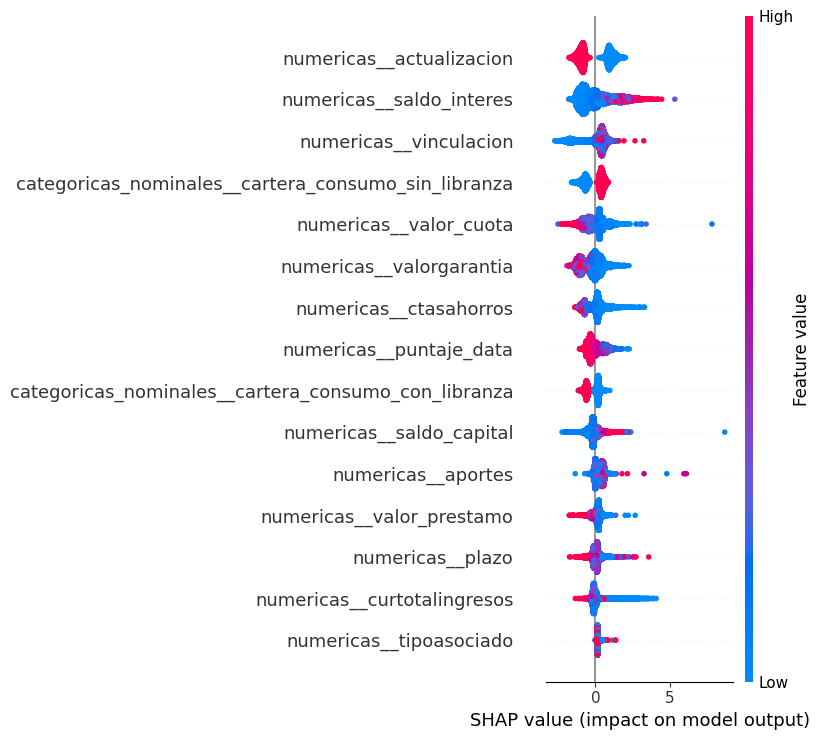

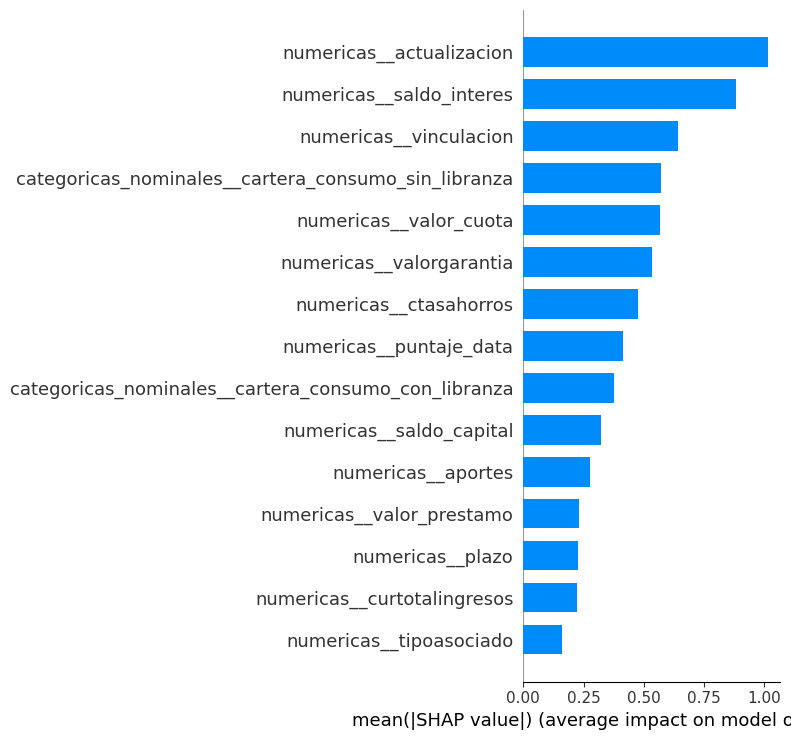

In [28]:
preprocessor = modelo_gbc.named_steps["preprocessing"]
classifier = modelo_gbc.named_steps["classifier"]

explainer = shap.TreeExplainer(classifier)

shap_values = explainer.shap_values(X_train_transformed)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    max_display=15
)

shap.summary_plot(
    shap_values,
    X_train_transformed,
    plot_type="bar",
    max_display=15
)


El análisis de interpretabilidad mediante SHAP para el modelo GBC permitió confirmar gran parte de los hallazgos obtenidos previamente con la importancia de variables tradicional del modelo.

Las dos variables más importantes se mantienen exactamente en las mismas posiciones observadas anteriormente: actualizacion continúa siendo la variable con mayor impacto dentro del modelo, seguida por saldo_interes. Esto refuerza la idea de que tanto el estado de actualización de la información del cliente como el comportamiento de los intereses asociados al crédito son factores fundamentales en la predicción del impago.

Uno de los cambios más interesantes aparece en la variable vinculacion, la cual aumenta considerablemente su relevancia en el análisis SHAP, posicionándose como la tercera variable más importante del modelo. En el análisis previo esta variable tenía importancia, pero no parecía tan dominante. Este resultado podría indicar que el tiempo de relación del cliente con la cooperativa tiene un impacto más fuerte sobre las predicciones individuales de lo que inicialmente sugería la importancia tradicional del modelo.

Por otro lado, cartera_consumo_sin_libranza, que anteriormente ocupaba una posición más alta, desciende ligeramente, aunque continúa formando parte del grupo de variables más influyentes. Esto mantiene coherencia con el EDA realizado previamente, donde este tipo de cartera mostraba una mayor proporción de casos de impago.

De manera general, el análisis SHAP del modelo GBC conserva una estructura muy similar a la observada tanto en el análisis previo del mismo modelo como en el modelo LightGBM. Las variables financieras y de comportamiento crediticio continúan dominando claramente las decisiones del modelo, mientras que las variables demográficas y sociales siguen teniendo una relevancia considerablemente menor.

Variables como sexo, grupo_edad, intestrato y otras características demográficas permanecen relegadas a posiciones bajas de importancia, lo cual sugiere que el modelo obtiene mucho más valor predictivo de variables relacionadas con estabilidad financiera, historial económico y comportamiento del crédito que de atributos personales del cliente.

En conclusión, tanto el modelo GBC como el modelo LightGBM muestran una lógica consistente: el riesgo de impago parece estar mucho más relacionado con variables financieras y de comportamiento económico que con variables demográficas tradicionales.

# **Conclusiones**

En términos generales, los análisis de importancia de variables e interpretabilidad realizados sobre los modelos LightGBM y GBC permitieron identificar patrones consistentes respecto a los factores más relevantes en la predicción de impago dentro del dataset de la cooperativa.

Tanto las métricas tradicionales de importancia como los análisis basados en SHAP mostraron resultados similares, evidenciando que las variables con mayor capacidad predictiva son principalmente aquellas relacionadas con el comportamiento financiero y crediticio de los clientes. Variables como actualizacion, saldo_interes, cartera, puntaje_data, ctasahorros, valor_cuota, vinculacion y valorgarantia se mantuvieron constantemente entre las más influyentes en ambos modelos.

Por el contrario, las variables demográficas y sociales como sexo, grupo_edad, intestrato o grupo_ciudad presentaron niveles de importancia considerablemente menores, lo que sugiere que estas características aportan poca información relevante para la predicción del default en comparación con las variables financieras.

Además, los resultados obtenidos guardan coherencia con gran parte de lo observado durante el EDA. Por ejemplo, variables como actualizacion, el tipo de cartera o el puntaje_data ya mostraban diferencias importantes entre clientes con y sin impago, y posteriormente estas mismas variables fueron identificadas por los modelos como algunas de las más determinantes en las predicciones.

Otro aspecto importante es que, aunque ambos modelos presentan una lógica bastante similar, SHAP permitió complementar el análisis tradicional de importancia mostrando el impacto promedio real de las variables sobre las predicciones individuales. Gracias a esto fue posible obtener una interpretación más transparente del comportamiento interno de los modelos.

En conclusión, los modelos desarrollados parecen apoyarse principalmente en indicadores asociados a estabilidad financiera, capacidad económica e historial crediticio del cliente para estimar el riesgo de impago, manteniendo una lógica coherente tanto desde la perspectiva estadística como desde el contexto del negocio financiero.